## Step 4 — Build & Train Convolutional Autoencoder
**Dissertation: TinyML-Based Anomaly Detection**  
**Author: Thondupu Dileep | 2024AB05233**

Builds a lightweight CAE, trains on normal CWRU data only, saves best model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import json
import os
import time

%matplotlib inline

tf.random.set_seed(42)
np.random.seed(42)

DATA_PATH  = '../data/processed/cwru_processed.npz'
MODEL_DIR  = '../models'
RESULT_DIR = '../results'
PLOTS_DIR  = '../results/plots'

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices("GPU")) > 0)


TensorFlow version: 2.15.0
GPU available: False


### 4.1 — Load preprocessed data

In [2]:
data    = np.load(DATA_PATH, allow_pickle=True)
X_all   = data['X_raw']
y       = data['y_labels']
y_names = data['y_names']

# training uses ONLY normal windows
X_normal = X_all[y == 0][..., np.newaxis].astype(np.float32)   # (N, 2048, 1)
X_fault  = X_all[y != 0][..., np.newaxis].astype(np.float32)

print(f'Normal windows : {len(X_normal)}')
print(f'Fault  windows : {len(X_fault)}')
print(f'Input shape    : {X_normal.shape}')

Normal windows : 471
Fault  windows : 4264
Input shape    : (471, 2048, 1)


In [3]:
# 80/20 train-val split on normal data
n_train  = int(len(X_normal) * 0.8)
idx      = np.random.permutation(len(X_normal))
X_train  = X_normal[idx[:n_train]]
X_val    = X_normal[idx[n_train:]]

print(f'Train : {len(X_train)}')
print(f'Val   : {len(X_val)}')

Train : 376
Val   : 95


### 4.2 — Build the Convolutional Autoencoder

In [4]:
def build_cae(input_len=2048, bottleneck=32):
    inp = keras.Input(shape=(input_len, 1))

    # encoder
    x = layers.Conv1D(16, 7, strides=2, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(32, 5, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(16, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    shape_before = x.shape[1:]
    x = layers.Flatten()(x)
    x = layers.Dense(bottleneck, activation='relu', name='bottleneck')(x)

    # decoder
    x = layers.Dense(shape_before[0] * shape_before[1], activation='relu')(x)
    x = layers.Reshape(shape_before)(x)
    x = layers.Conv1DTranspose(16, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1DTranspose(32, 5, strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1DTranspose(16, 7, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv1D(1, 1, padding='same', activation='linear')(x)
    x = layers.Cropping1D((0, x.shape[1] - input_len))(x)

    return keras.Model(inputs=inp, outputs=x, name='CWRU_CAE')

model = build_cae(input_len=2048, bottleneck=32)
model.summary()


Model: "CWRU_CAE"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 2048, 1)]         0         
                                                                 
 conv1d (Conv1D)             (None, 1024, 16)          128       
                                                                 
 batch_normalization (Batch  (None, 1024, 16)          64        
 Normalization)                                                  
                                                                 
 conv1d_1 (Conv1D)           (None, 512, 32)           2592      
                                                                 
 batch_normalization_1 (Bat  (None, 512, 32)           128       
 chNormalization)                                                
                                                                 
 conv1d_2 (Conv1D)           (None, 256, 16)           15

In [5]:
# parameter count and estimated size
total_params = model.count_params()
size_kb_f32  = total_params * 4 / 1024
size_kb_int8 = total_params * 1 / 1024

print(f'Total parameters : {total_params:,}')
print(f'Float32 size     : {size_kb_f32:.1f} KB')
print(f'Int8 (estimated) : {size_kb_int8:.1f} KB')

Total parameters : 277,985
Float32 size     : 1085.9 KB
Int8 (estimated) : 271.5 KB


### 4.3 — Compile & Train

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

ckpt_path = os.path.join(MODEL_DIR, 'cae_model.h5')

callbacks = [
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor='val_loss',
                                     save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                   restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=8, min_lr=1e-6, verbose=1),
]

print('Starting training...')
t0      = time.time()
history = model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    batch_size=64,
    epochs=100,
    callbacks=callbacks,
    verbose=1
)
print(f'\nTraining done in {(time.time()-t0)/60:.1f} minutes')

Starting training...
Epoch 1/100


6/6 [==============================] - ETA: 0s - loss: 2.0704 - mae: 1.1399
Epoch 1: val_loss improved from inf to 1.00039, saving model to ../models\cae_model.h5
6/6 [==============================] - 3s 169ms/step - loss: 2.0704 - mae: 1.1399 - val_loss: 1.0004 - val_mae: 0.8007 - lr: 0.0010
Epoch 2/100
1/6 [====>.........................] - ETA: 0s - loss: 1.4488 - mae: 0.9518

C:\Users\lrlacm\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


6/6 [==============================] - ETA: 0s - loss: 1.2837 - mae: 0.8967
Epoch 2: val_loss did not improve from 1.00039
6/6 [==============================] - 0s 75ms/step - loss: 1.2837 - mae: 0.8967 - val_loss: 1.0008 - val_mae: 0.8012 - lr: 0.0010
Epoch 3/100
5/6 [========================>.....] - ETA: 0s - loss: 1.0855 - mae: 0.8285
Epoch 3: val_loss did not improve from 1.00039
6/6 [==============================] - 0s 70ms/step - loss: 1.0810 - mae: 0.8272 - val_loss: 1.0016 - val_mae: 0.8019 - lr: 0.0010
Epoch 4/100
6/6 [==============================] - ETA: 0s - loss: 1.0233 - mae: 0.8076
Epoch 4: val_loss did not improve from 1.00039
6/6 [==============================] - 0s 74ms/step - loss: 1.0233 - mae: 0.8076 - val_loss: 1.0026 - val_mae: 0.8026 - lr: 0.0010
Epoch 5/100
5/6 [========================>.....] - ETA: 0s - loss: 1.0003 - mae: 0.7996
Epoch 5: val_loss did not improve from 1.00039
6/6 [==============================] - 0s 69ms/step - loss: 1.0007 - mae: 0.799

### 4.4 — Training curves

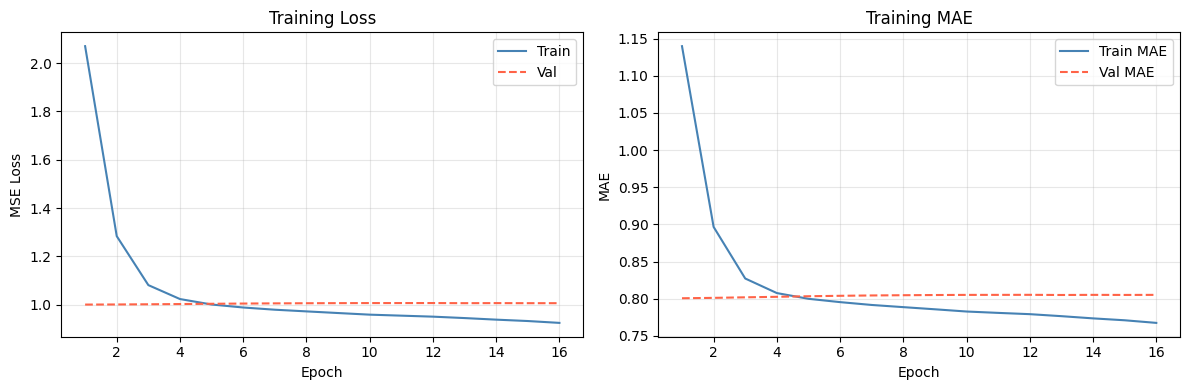

Best val_loss : 1.000391  at epoch 1


In [7]:
h = history.history
epochs_ran = range(1, len(h['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_ran, h['loss'],     label='Train', color='steelblue')
axes[0].plot(epochs_ran, h['val_loss'], label='Val',   color='tomato', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, h['mae'],     label='Train MAE', color='steelblue')
axes[1].plot(epochs_ran, h['val_mae'], label='Val MAE',   color='tomato', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Training MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'training_loss.png'), dpi=150)
plt.show()
print(f'Best val_loss : {min(h["val_loss"]):.6f}  at epoch {h["val_loss"].index(min(h["val_loss"]))+1}')

In [8]:
# save history to json
os.makedirs(RESULT_DIR, exist_ok=True)
with open(os.path.join(RESULT_DIR, 'training_history.json'), 'w') as f:
    json.dump({k: [float(v) for v in vals] for k, vals in h.items()}, f, indent=2)
print('History saved.')

History saved.


### 4.5 — Reconstruction quality check

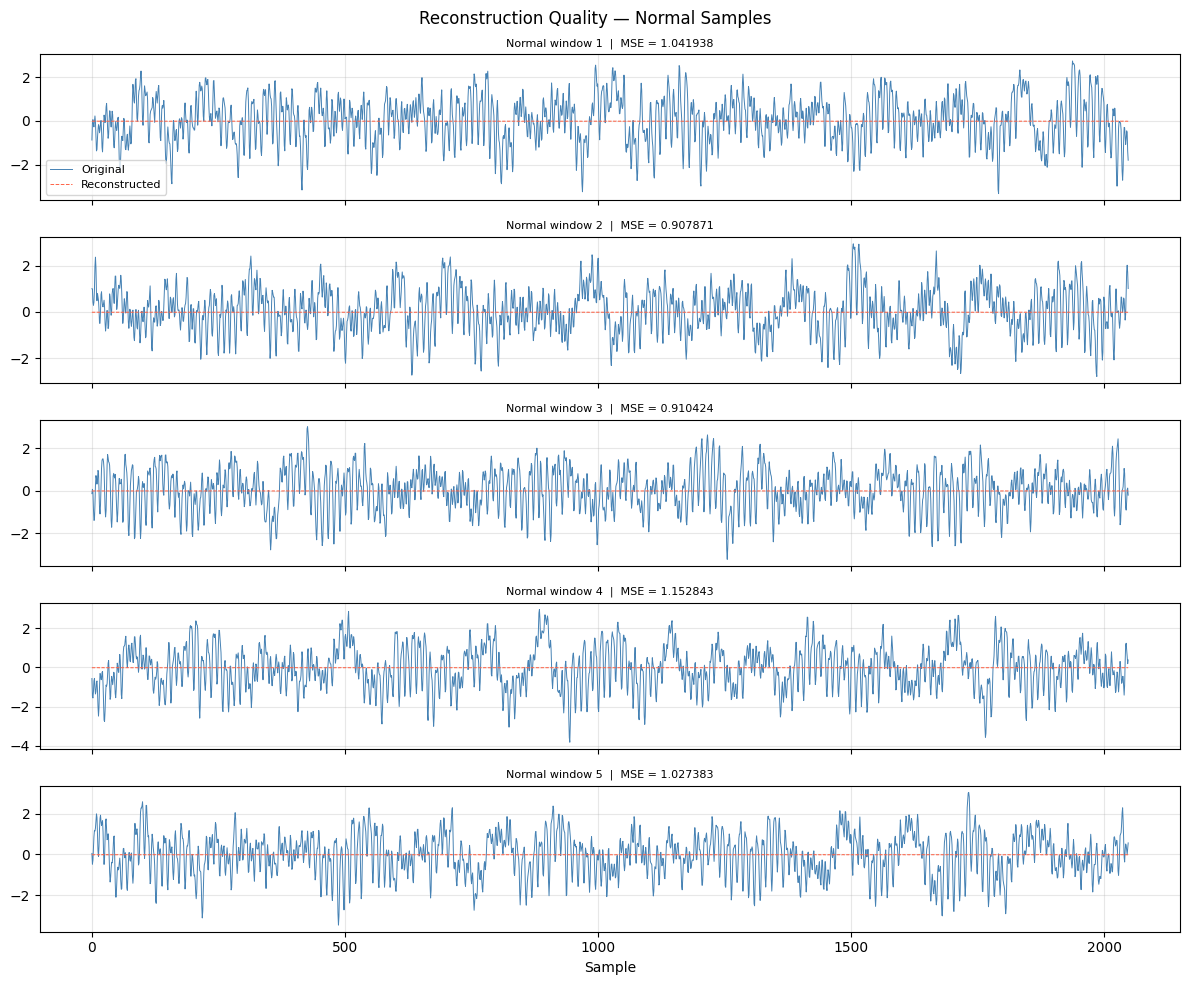

In [9]:
# load best weights and reconstruct a few normal samples
model.load_weights(ckpt_path)

sample_n = X_val[:5]
recon_n  = model.predict(sample_n, verbose=0)

fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(sample_n[i, :, 0], label='Original',      linewidth=0.7, color='steelblue')
    ax.plot(recon_n[i,  :, 0], label='Reconstructed', linewidth=0.7, color='tomato', linestyle='--')
    mse = float(np.mean((sample_n[i] - recon_n[i])**2))
    ax.set_title(f'Normal window {i+1}  |  MSE = {mse:.6f}', fontsize=8)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

axes[-1].set_xlabel('Sample')
plt.suptitle('Reconstruction Quality — Normal Samples')
plt.tight_layout()
plt.show()

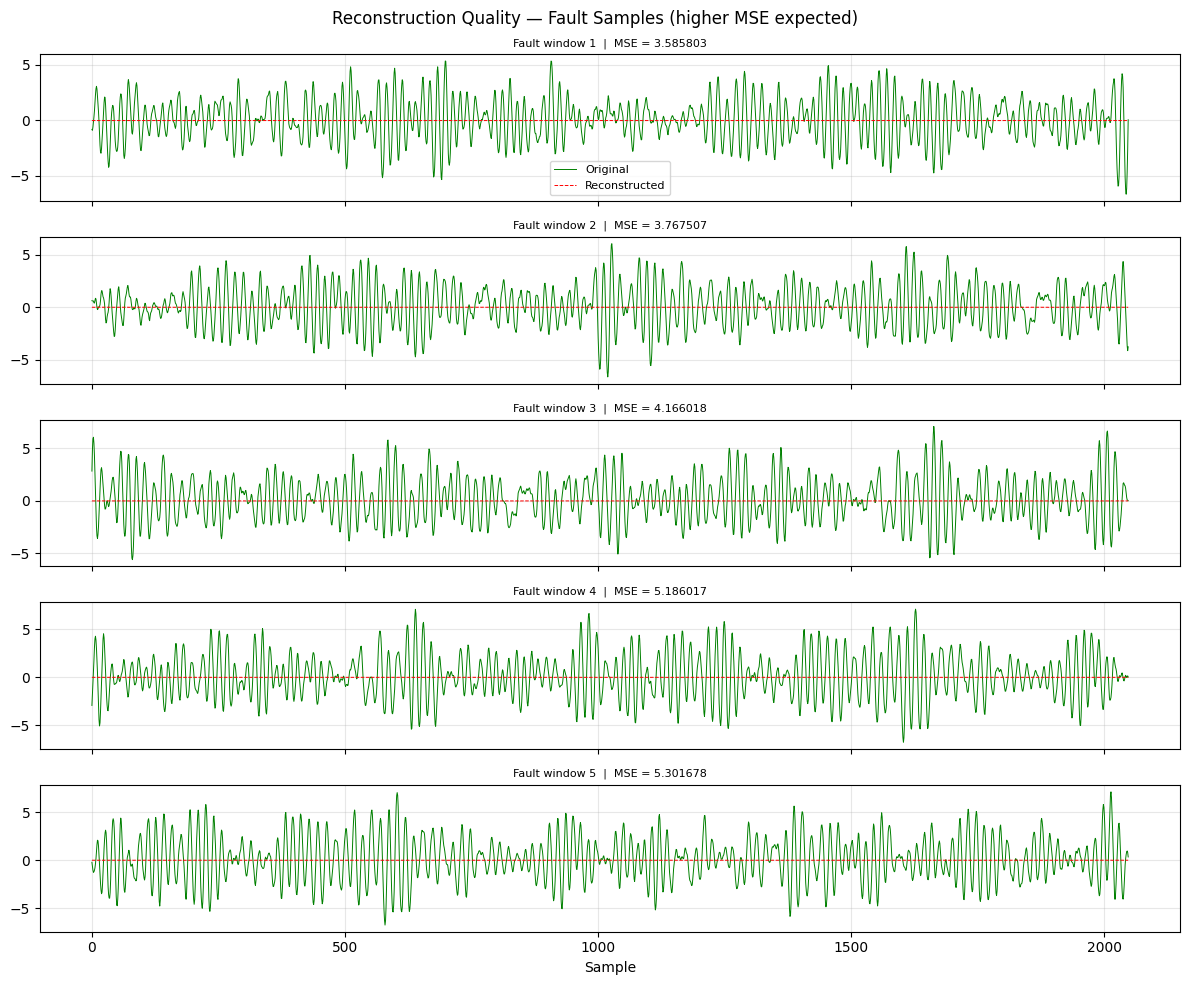

In [10]:
# same check on fault samples
sample_f = X_fault[:5]
recon_f  = model.predict(sample_f, verbose=0)

fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(sample_f[i, :, 0], label='Original',      linewidth=0.7, color='green')
    ax.plot(recon_f[i,  :, 0], label='Reconstructed', linewidth=0.7, color='red', linestyle='--')
    mse = float(np.mean((sample_f[i] - recon_f[i])**2))
    ax.set_title(f'Fault window {i+1}  |  MSE = {mse:.6f}', fontsize=8)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

axes[-1].set_xlabel('Sample')
plt.suptitle('Reconstruction Quality — Fault Samples (higher MSE expected)')
plt.tight_layout()
plt.show()

### 4.6 — MSE separation (normal vs all fault types)

In [11]:
# compute reconstruction MSE for every window
X_all_ch = X_all[..., np.newaxis].astype(np.float32)
recon_all = model.predict(X_all_ch, batch_size=64, verbose=1)
mse_all   = np.mean((X_all_ch - recon_all)**2, axis=(1, 2))

mse_normal = mse_all[y == 0]
mse_fault  = mse_all[y != 0]

print(f'Normal MSE  — mean: {mse_normal.mean():.6f}  std: {mse_normal.std():.6f}')
print(f'Fault  MSE  — mean: {mse_fault.mean():.6f}  std: {mse_fault.std():.6f}')
print(f'Separation ratio  : {mse_fault.mean()/mse_normal.mean():.2f}x')

74/74 [==============================] - 1s 19ms/step
Normal MSE  — mean: 1.000140  std: 0.072187
Fault  MSE  — mean: 55.149624  std: 83.642380
Separation ratio  : 55.14x


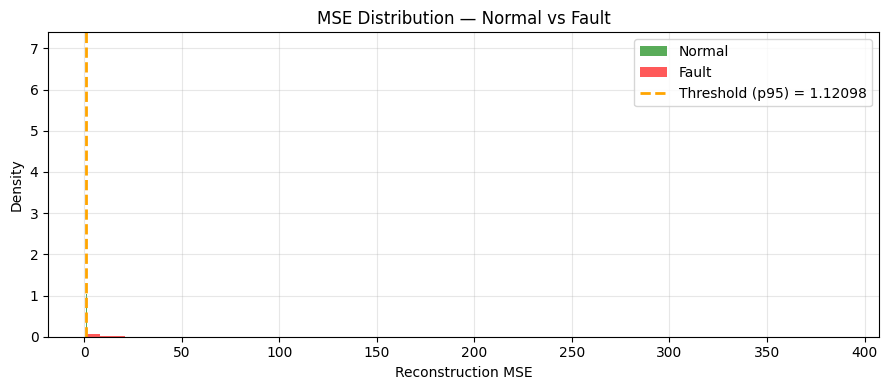

In [12]:
# histogram — normal vs fault MSE
plt.figure(figsize=(9, 4))
plt.hist(mse_normal, bins=60, alpha=0.65, color='green', label='Normal',  density=True)
plt.hist(mse_fault,  bins=60, alpha=0.65, color='red',   label='Fault',   density=True)

thresh = np.percentile(mse_normal, 95)
plt.axvline(thresh, color='orange', linestyle='--', linewidth=2,
             label=f'Threshold (p95) = {thresh:.5f}')

plt.xlabel('Reconstruction MSE')
plt.ylabel('Density')
plt.title('MSE Distribution — Normal vs Fault')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'mse_distribution.png'), dpi=150)
plt.show()

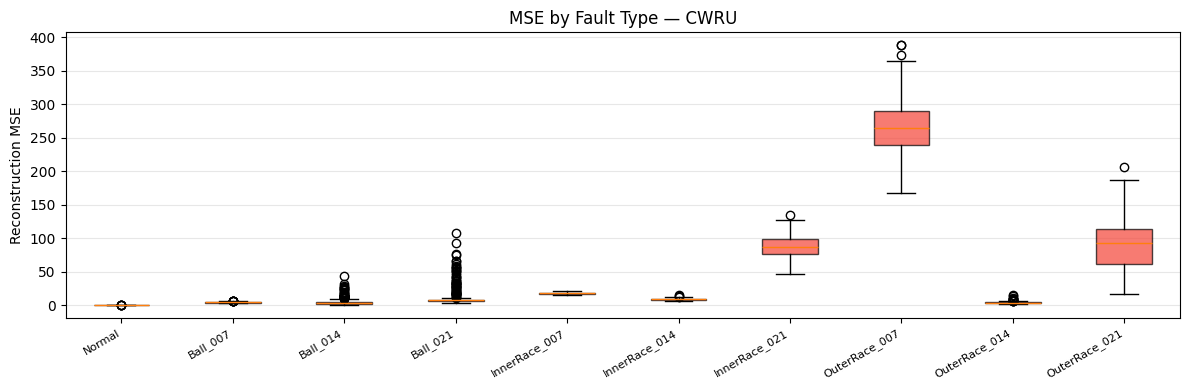

In [13]:
# MSE broken down per fault type — box plot
unique = list(dict.fromkeys(y_names))   # preserve original order
groups = [mse_all[y_names == n] for n in unique]

fig, ax = plt.subplots(figsize=(12, 4))
bp = ax.boxplot(groups, patch_artist=True, widths=0.5)

for patch, name in zip(bp['boxes'], unique):
    patch.set_facecolor('#4CAF50' if name == 'Normal' else '#F44336')
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(unique)+1))
ax.set_xticklabels(unique, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Reconstruction MSE')
ax.set_title('MSE by Fault Type — CWRU')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'per_fault_mse.png'), dpi=150)
plt.show()

### 4.7 — Anomaly detection at threshold

In [14]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report

y_binary = (y > 0).astype(int)
threshold = np.percentile(mse_all[y == 0], 95)
y_pred    = (mse_all > threshold).astype(int)

f1  = f1_score(y_binary, y_pred, zero_division=0)
auc = roc_auc_score(y_binary, mse_all)

print(f'Threshold (p95) : {threshold:.6f}')
print(f'F1-Score        : {f1:.4f}')
print(f'AUC-ROC         : {auc:.4f}')
print()
print(classification_report(y_binary, y_pred, target_names=['Normal','Fault']))

Threshold (p95) : 1.120975
F1-Score        : 0.9972
AUC-ROC         : 1.0000

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97       471
       Fault       0.99      1.00      1.00      4264

    accuracy                           0.99      4735
   macro avg       1.00      0.97      0.99      4735
weighted avg       0.99      0.99      0.99      4735



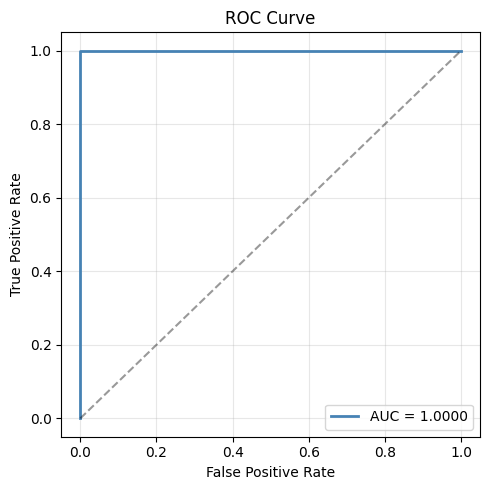

In [15]:
# ROC curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_binary, mse_all)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc:.4f}')
plt.plot([0,1],[0,1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'roc_curve.png'), dpi=150)
plt.show()

### 4.8 — Visualise bottleneck (encoder output)

In [16]:
# build encoder-only sub-model to inspect the 32-dim bottleneck
encoder = keras.Model(inputs=model.input,
                       outputs=model.get_layer('bottleneck').output)

# get bottleneck representations
z_all = encoder.predict(X_all_ch, batch_size=64, verbose=0)   # (N, 32)
print(f'Bottleneck shape: {z_all.shape}')

# t-SNE on a sample of 1500 windows
from sklearn.manifold import TSNE

sample_idx  = np.random.choice(len(z_all), size=1500, replace=False)
z_sample    = z_all[sample_idx]
y_sample    = y[sample_idx]
names_sample = y_names[sample_idx]

print('Running t-SNE...')
tsne   = TSNE(n_components=2, random_state=42, perplexity=40)
z_2d   = tsne.fit_transform(z_sample)
print('Done.')

Bottleneck shape: (4735, 32)
Running t-SNE...
Done.


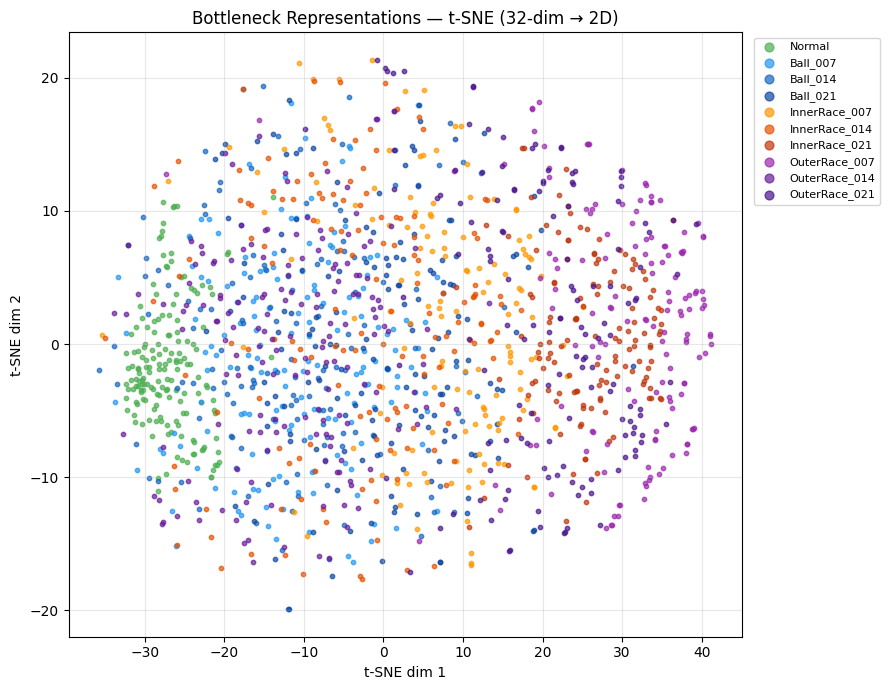

In [17]:
# colour each fault type differently
fault_colors = {
    'Normal'        : '#4CAF50',
    'Ball_007'      : '#2196F3',
    'Ball_014'      : '#1565C0',
    'Ball_021'      : '#0D47A1',
    'InnerRace_007' : '#FF9800',
    'InnerRace_014' : '#E65100',
    'InnerRace_021' : '#BF360C',
    'OuterRace_007' : '#9C27B0',
    'OuterRace_014' : '#6A1B9A',
    'OuterRace_021' : '#4A148C',
}

plt.figure(figsize=(9, 7))
for name, color in fault_colors.items():
    mask = (names_sample == name)
    if mask.sum() == 0:
        continue
    plt.scatter(z_2d[mask, 0], z_2d[mask, 1],
                s=10, alpha=0.7, color=color, label=name)

plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
plt.title('Bottleneck Representations — t-SNE (32-dim → 2D)')
plt.legend(markerscale=2, fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'tsne_bottleneck.png'), dpi=150, bbox_inches='tight')
plt.show()

### Summary

In [18]:
print('=== Step 4 Results ===')
print(f'Model parameters : {model.count_params():,}')
print(f'Float32 size     : {model.count_params()*4/1024:.1f} KB')
print(f'Best val loss    : {min(h["val_loss"]):.6f}')
print(f'F1-Score         : {f1:.4f}')
print(f'AUC-ROC          : {auc:.4f}')
print(f'Model saved to   : {ckpt_path}')
print('\nNext: Step 5 — Pruning + Quantization → run convert_tflite.py')

=== Step 4 Results ===
Model parameters : 277,985
Float32 size     : 1085.9 KB
Best val loss    : 1.000391
F1-Score         : 0.9972
AUC-ROC          : 1.0000
Model saved to   : ../models\cae_model.h5

Next: Step 5 — Pruning + Quantization → run convert_tflite.py
